# Análisis exploratorio HR Analytics


Análizare las siguientes preguntas de negocio:

- ¿Quiénes se van y por qué? (Perfil del Desertor)
- ¿El dinero es la causa principal o es el agotamiento?
- ¿La distancia al trabajo influye en la renuncia?
- ¿Falta de crecimiento o falta de reconocimiento?
- ¿Qué tan exactos podemos ser prediciendo quién se irá el próximo mes? (La pregunta de ML)

In [1]:

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sqlite3
import squarify


### Configuración de gráficos 

In [2]:
plt.rcParams["figure.figsize"] = (20,10)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'

In [3]:

BASE_DIR = Path.cwd().parent.parent
CSV_DIR = BASE_DIR / "data" / "raw"
DB_PATH = BASE_DIR / "data" / "database"
ASSETS_PATH = BASE_DIR / "src" / "visualization"
PROC_PATH = BASE_DIR / "data" / "processed"


In [4]:
#Creo la coneccion con sql
conn = sqlite3.connect(DB_PATH / "empleados.db")

In [5]:
from src.features.iniciar_dataframe import informacion_df

In [6]:

df = informacion_df(CSV_DIR / "employee_optimo.csv")

▶ Head (5 filas):


,Unnamed: 0,Age,Target,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,...,1,80,0,8,0,1,6,4,0,5
1,1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,...,4,80,1,10,3,3,10,7,1,7
2,2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,...,2,80,0,7,3,3,0,0,0,0
3,3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,...,3,80,0,8,3,3,8,7,3,0
4,4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,...,4,80,1,6,3,3,2,2,2,2



▶ Info del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Unnamed: 0                1470 non-null   int64
 1   Age                       1470 non-null   int64
 2   Target                    1470 non-null   int64
 3   BusinessTravel            1470 non-null   str  
 4   DailyRate                 1470 non-null   int64
 5   Department                1470 non-null   str  
 6   DistanceFromHome          1470 non-null   int64
 7   Education                 1470 non-null   int64
 8   EducationField            1470 non-null   str  
 9   EmployeeCount             1470 non-null   int64
 10  EmployeeNumber            1470 non-null   int64
 11  EnvironmentSatisfaction   1470 non-null   int64
 12  Gender                    1470 non-null   str  
 13  HourlyRate                1470 non-null   int64
 14  JobInvolvement            14

,Unnamed: 0,Age,Target,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,734.500000,36.923810,0.161224,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.367863,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,0.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,367.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,734.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1101.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1469.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000



▶ Tipos de datos:
Unnamed: 0                  int64
Age                         int64
Target                      int64
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            i

### Diccionario de valores

In [7]:
diccionario_valores = {
    "Target" : {
      1 : "Yes",
      0 : "No"  
    },
    "Education" : {
        1 : "Below College",
        2 : 'College',
        3 : 'Bachelor',
        4 : 'Master',
        5 : 'Doctor'
    },
    "EnvironmentSatisfaction" : {
        1 : "Low",
        2 : "Medium",
        3 : "High",
        4 : "Very High"
    },
    "JobInvolvement" :{
        1 : "Low",
        2 : "Medium",
        3 : "High",
        4 : "Very High"
    },
    "JobSatisfaction" : {
        1 : "Low",
        2 : "Medium",
        3 : "High",
        4 : "Very High"
    },
    "PerformanceRating": {
        1 : "Low",
        2 : "Good",
        3 : "Excellent",
        4 : "Outstanding"
    },
    "RelationshipSatisfaction" : {
        1 : "Low",
        2 : "Medium",
        3 : "High",
        4 : "Very High"
    },
    "WorkLifeBalance" : {
        1 : "Bad",
        2 : "Good",
        3 : "Better",
        4 : "Best"
    }
}

In [8]:
#creo una copia del dataframe con los nombre de los valores para que sea mas visual.

df_visual = df.copy()

for col, mapeo in diccionario_valores.items():
    if col in df_visual.columns:
        df_visual[col] = df_visual[col].map(mapeo)

In [9]:
df_visual.head(5)

,Unnamed: 0,Age,Target,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0,41,Yes,Travel_Rarely,1102,Sales,1,College,Life Sciences,1,...,Low,80,0,8,0,Bad,6,4,0,5
1,1,49,No,Travel_Frequently,279,Research & Development,8,Below College,Life Sciences,1,...,Very High,80,1,10,3,Better,10,7,1,7
2,2,37,Yes,Travel_Rarely,1373,Research & Development,2,College,Other,1,...,Medium,80,0,7,3,Better,0,0,0,0
3,3,33,No,Travel_Frequently,1392,Research & Development,3,Master,Life Sciences,1,...,High,80,0,8,3,Better,8,7,3,0
4,4,27,No,Travel_Rarely,591,Research & Development,2,Below College,Medical,1,...,Very High,80,1,6,3,Better,2,2,2,2


In [10]:

from src.features.functions import tramo_edad
from src.features.functions import cercania


df_visual["Tramo_Age"] = df_visual["Age"].apply(tramo_edad)
df_visual["Cercania"] = df_visual["DistanceFromHome"].apply(cercania)

df_visual.to_sql("empleados_visual_procesados.db", conn, if_exists='replace', index=False)

print("Datos guardados exitosamente")

Datos guardados exitosamente


### Limpieza de datos

In [11]:
df_visual.isna().sum()

Unnamed: 0                  0
Age                         0
Target                      0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCur

No presenta datos nulos el dataframe

In [12]:
df_visual.duplicated().sum()

np.int64(0)

No presenta filas duplicadas el dataframe

- ¿Quiénes se van y por qué? (Perfil del Desertor)

Analizaremos las variables Target, Age, Gender, MaritalStatus,DistanceFromHome

In [13]:
#Análisis Target vs Age
target_vs_age = df_visual.groupby("Target")["Tramo_Age"].value_counts().reset_index()
target_vs_age

,Target,Tramo_Age,count
0,No,Joven,569
1,No,Adulto,539
2,No,Adulto Mayor,125
3,Yes,Joven,160
4,Yes,Adulto,59
5,Yes,Adulto Mayor,18


In [14]:
target_rate = df_visual.groupby("Target")["Tramo_Age"].value_counts(normalize=True).unstack() * 100

print(target_rate)

Tramo_Age     Adulto  Adulto Mayor      Joven
Target                                       
No         43.714517     10.137875  46.147607
Yes        24.894515      7.594937  67.510549


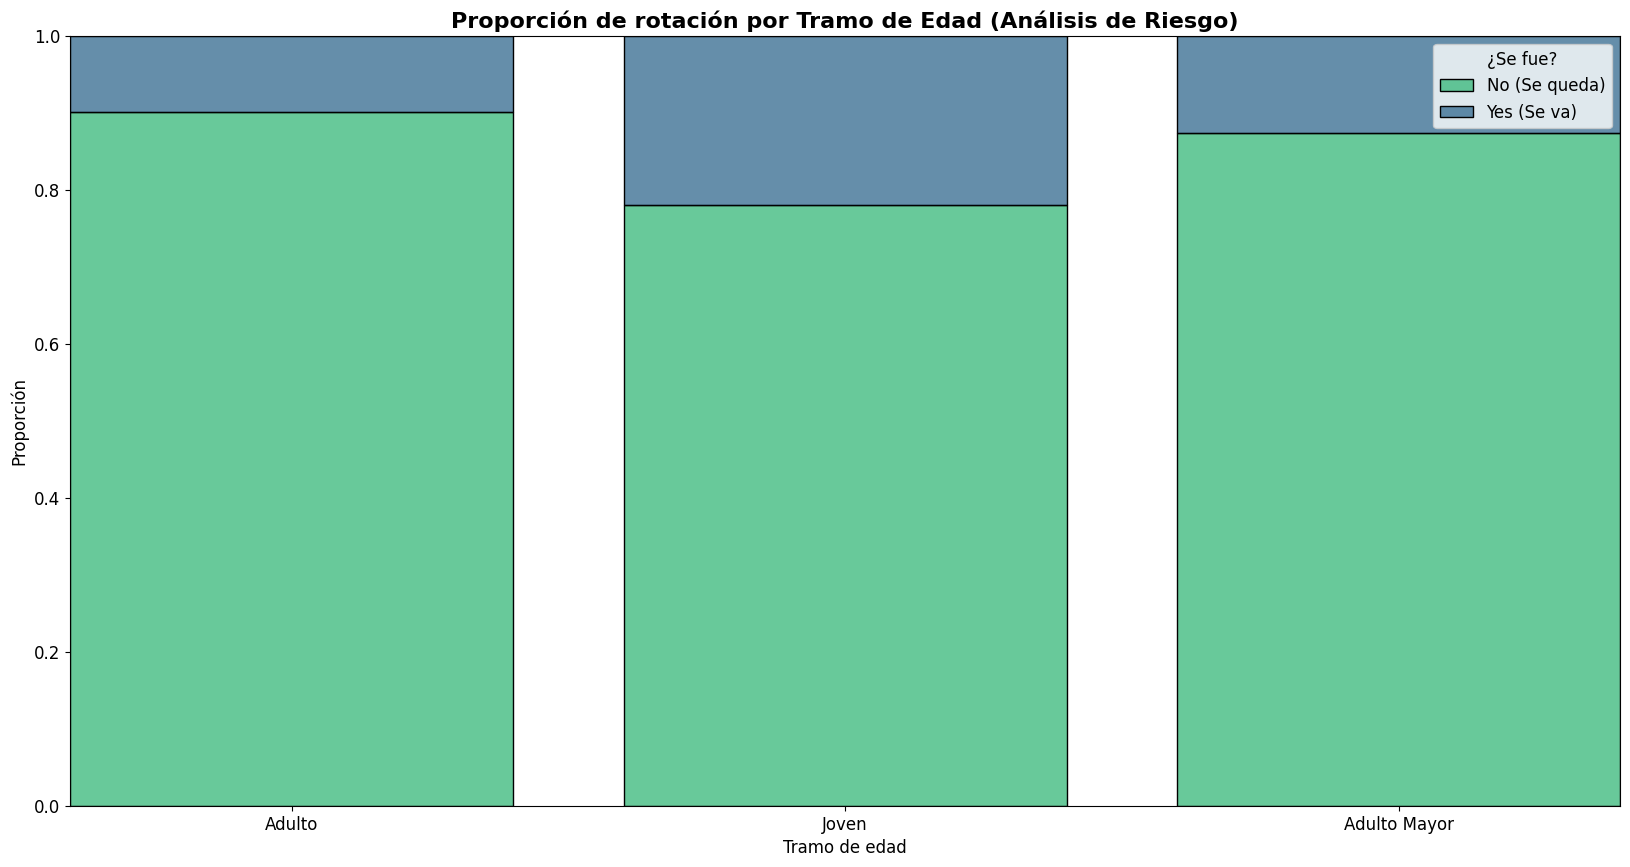

In [15]:
sns.histplot(data=df_visual, x="Tramo_Age", hue="Target", multiple="fill", shrink=0.8, palette="viridis")
plt.title("Proporción de rotación por Tramo de Edad (Análisis de Riesgo)", fontsize=16, fontweight= "bold")
plt.xlabel("Tramo de edad")
plt.ylabel("Proporción")
plt.legend(title='¿Se fue?', labels=['No (Se queda)', 'Yes (Se va)'])
plt.savefig(ASSETS_PATH / "Proporción_de_rotación_por_tramo_de_edad.png")
plt.show()
plt.close()

Insights:
- Vemos que el tramo de edad que más movimiento de salida tiene es el de jovenes (18 a 35 años),
- De todas las bajas el 67% son gente Joven,
- La estabilidad es la norma en perfiles Adultos y Adultos Mayores,

In [16]:
target_analisis = df_visual.groupby(["Tramo_Age","Gender","MaritalStatus","Cercania"])["Target"].value_counts().reset_index().sort_values("count", ascending=False)
target_analisis

,Tramo_Age,Gender,MaritalStatus,Cercania,Target,count
114,Joven,Male,Married,Very Near,No,70
33,Adulto,Male,Married,Very Near,No,67
11,Adulto,Female,Married,Very Near,No,51
122,Joven,Male,Single,Very Near,No,50
108,Joven,Male,Married,Far,No,44
...,...,...,...,...,...,...
62,Adulto Mayor,Male,Divorced,Very Near,Yes,1
64,Adulto Mayor,Male,Married,Medium,No,1
74,Adulto Mayor,Male,Single,Near,Yes,1
72,Adulto Mayor,Male,Single,Medium,Yes,1


In [17]:
target_analisis = target_analisis[target_analisis["Target"]=="Yes"]
df_yes = target_analisis.head(10)

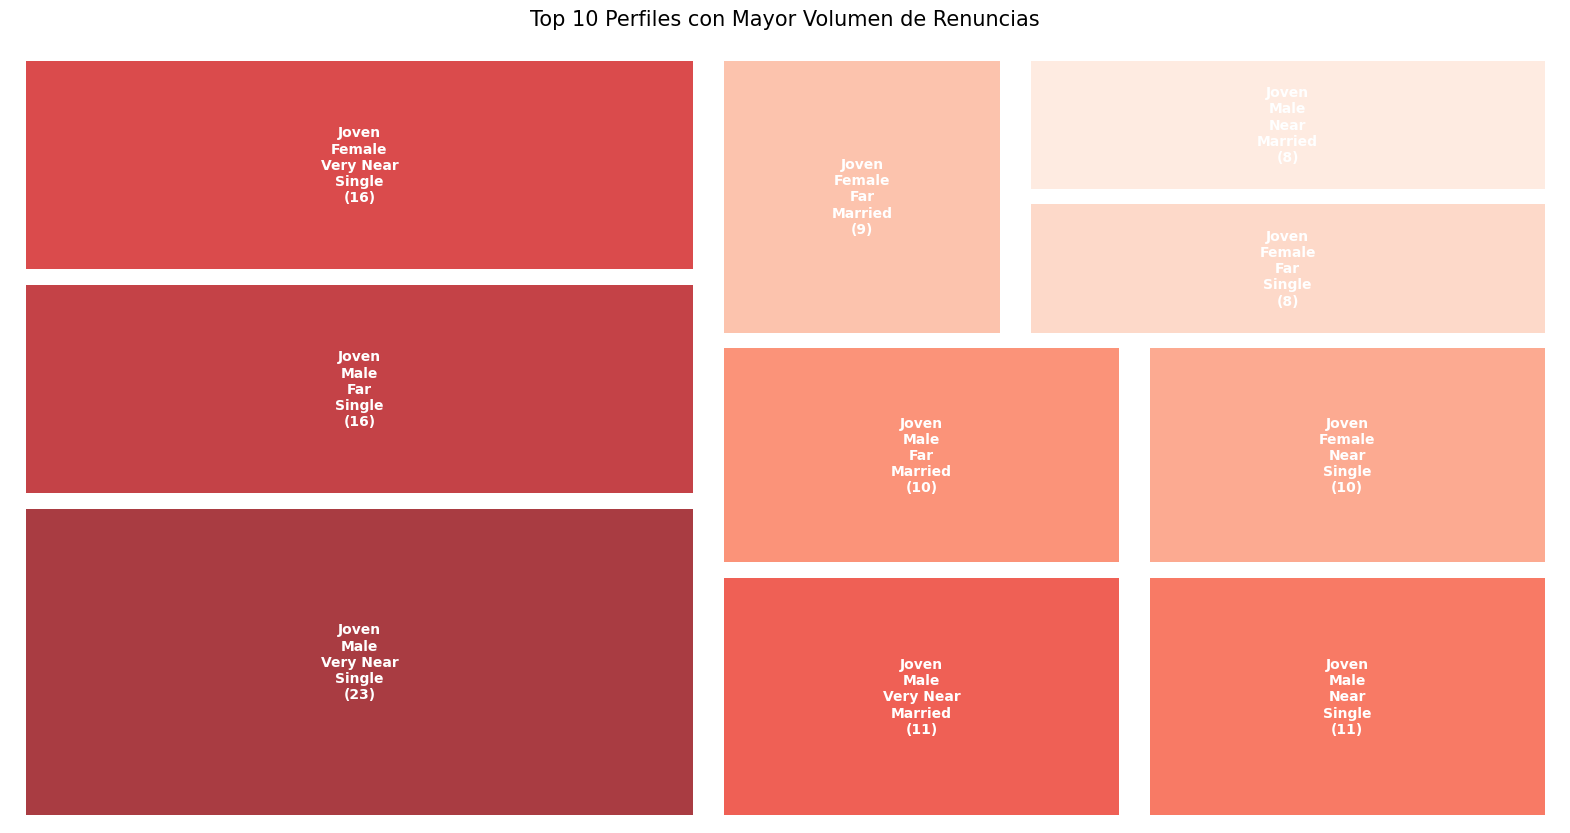

In [18]:
sizes = df_yes["count"].values
labels = [f"{row['Tramo_Age']}\n{row['Gender']}\n{row['Cercania']}\n{row['MaritalStatus']}\n({row['count']})" for _, row in df_yes.iterrows()]
colors = sns.color_palette("Reds_r", len(sizes))

squarify.plot(sizes=sizes, label=labels, alpha=0.8, pad=True, color=colors,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'})
plt.title("Top 10 Perfiles con Mayor Volumen de Renuncias", fontsize=15, pad=20)
plt.axis('off')
plt.savefig(ASSETS_PATH / "Top_10_mayor_volume_renuncia.png")
plt.show()
plt.close()

Insights:
- Confirmamos que los Jovenes solteros, sin importar el sexo, son los empleados que más rotación tienen dentro de la empresa.
- Un punto a ver es que la distancia con el trabajo no es un motivo relevante, ya que hay jovenes que viviendo muy cerca o muy lejos igualmente se van.
- Hay que revisar las politicas de retencion actuales (sueldo, beneficios, plan de carrera) para intentar retener al talento joven.

- ¿La distancia al trabajo influye en la renuncia?
No es una causa determinante.

- ¿El dinero es la causa principal o es el agotamiento?

Analizaremos las columnas: OverTime, YearsSinceLastPromotion

In [19]:
causa_df = df_visual[["Target","OverTime","YearsSinceLastPromotion"]]
causa_df

,Target,OverTime,YearsSinceLastPromotion
0,Yes,Yes,0
1,No,No,1
2,Yes,Yes,0
3,No,Yes,3
4,No,No,2
...,...,...,...
1465,No,No,0
1466,No,No,1
1467,No,Yes,0
1468,No,No,0


In [20]:
Overtime_df = causa_df.groupby("Target")["OverTime"].value_counts().reset_index()
Overtime_df

,Target,OverTime,count
0,No,No,944
1,No,Yes,289
2,Yes,Yes,127
3,Yes,No,110


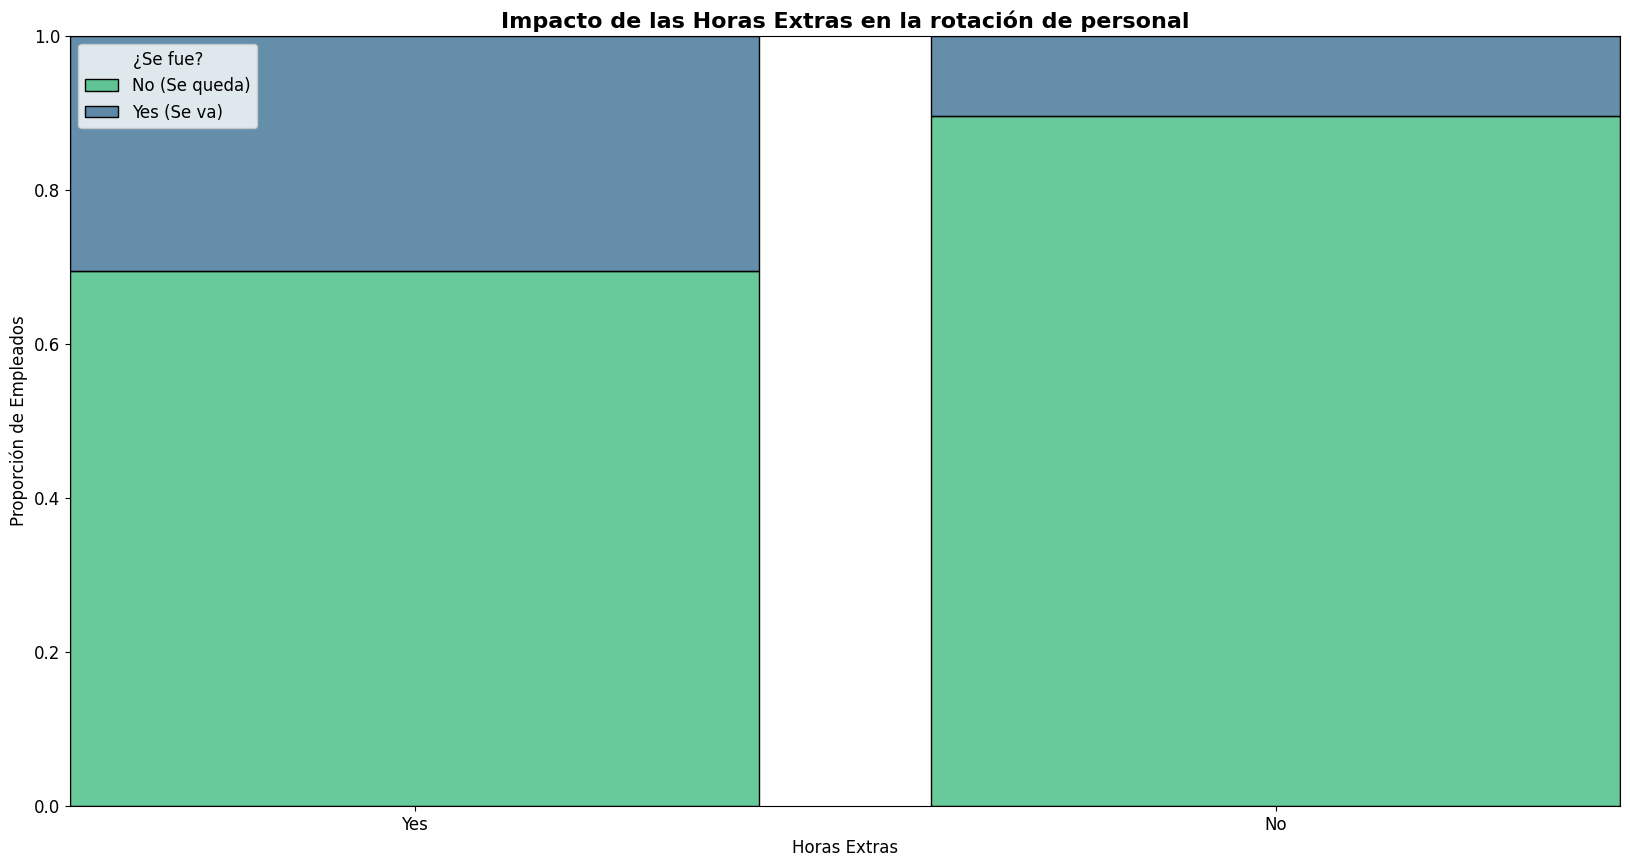

In [21]:
sns.histplot(data=df_visual, x="OverTime", hue="Target", multiple="fill", shrink=0.8, palette="viridis")
plt.title("Impacto de las Horas Extras en la rotación de personal", fontsize=16, fontweight= "bold")
plt.xlabel("Horas Extras")
plt.ylabel("Proporción de Empleados")
plt.legend(title='¿Se fue?', labels=['No (Se queda)', 'Yes (Se va)'])
plt.savefig(ASSETS_PATH / "Proporción_de_rotación_por_OverTime.png")
plt.show()
plt.close()

Insights:
- Podemos comprobar que solo el 10% de la rotación de los empleados se da en un ambito donde no tienen horas extras, sin embargo, encontramos un fuerte motivo por el cual triplica la motivación de los empleados a irse, siendo un 30% de la rotación la cual se da en el ambito de que los empleados hacen horas extras.


In [22]:
promotion_df = causa_df.groupby("Target")["YearsSinceLastPromotion"].value_counts().reset_index()
top3_last_promotion = promotion_df[promotion_df["Target"]=="Yes"].head(3)
top3_last_promotion

,Target,YearsSinceLastPromotion,count
16,Yes,0,110
17,Yes,1,49
18,Yes,2,27


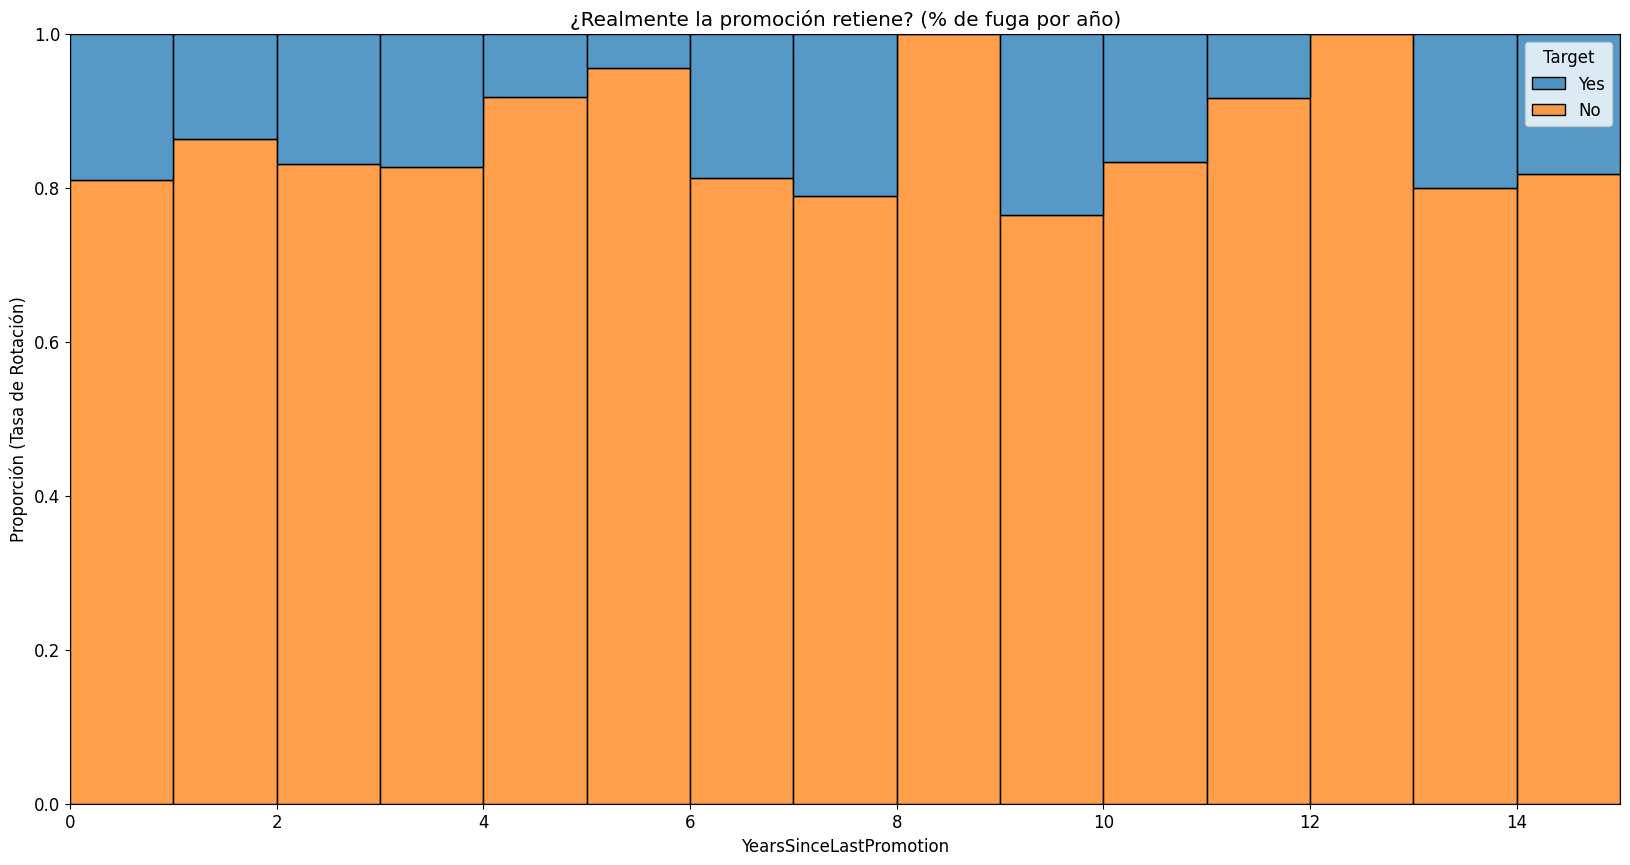

In [23]:
# Este gráfico te dirá el % de fuga por cada año desde la promoción
sns.histplot(data=df_visual, x="YearsSinceLastPromotion", hue="Target", multiple="fill", binwidth=1)
plt.title("¿Realmente la promoción retiene? (% de fuga por año)")
plt.ylabel("Proporción (Tasa de Rotación)")
plt.savefig(ASSETS_PATH / "Rotacion_promocion.png")
plt.show()
plt.close()

Insights:
- Hemos identificado 2 perfiles de fuga distintos respecto a las promociones:
* Fuga de oportunidad (corto plazo): Empleados que rotan inmediatamente despues de ser promovidos (0 a 3 años) Esto puede ser por aprovechar el ascenso para pasar a otra empresa por mejores condiciones o su nuevo trabajo no cumplio con las expectaivas.
* Fuga por Estancamiento (Largo Plazo): Un pico crítico de renuncias al alcanzar 7-9 año sin nuevos movimientos, sugiriendo que el ciclo de carrera se agota para estos momentos. 

Hay que reveer las politicas de promoción para que un empleado no sienta que tiene un techo en la empresa, sino que puede seguir creciendo. 
con respecto a las nuevas promociones, cuidarlas para poder formar y mantener a estas personas.


In [25]:
df_visual.to_csv(PROC_PATH / "datos_procesados_visual.csv", index=False)
print("Datos procesados guardados")

Datos procesados guardados
